#IDHM dos Municípios Brasileiros

###Cenário:

Um gestor público solicitou a uma consultoria um levantamento de diversas informações sobre os municípios brasileiros. O objetivo é estudar características e propor políticas adequadas nas áreas de Educação, Saúde e aumento de Renda. Para auxiliar nesse estudo, utilize a base de dados `cidades_do_brasil.xlsx`  e responda as perguntas.

###Panorama Geral:

O primeiro indicador a ser analisado é o Índice de Desenvolvimento Humano Municipal (IDHM), que é composto por três dimensões: longevidade, educação e renda. O índice varia de 0 a 1, sendo que quanto mais próximo de 1, maior o desenvolvimento humano.

---

###Inicialização



In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

dados = pd.read_excel('/content/gdrive/My Drive/AVD/JÚLIA DE SOUZA CALADO - cidades_do_brasil.xlsx', skiprows=3)
dados.head(5)

Mounted at /content/gdrive


,Município,Estado,IBGE_1-4,IDHM,IDHM_Renda,IDHM_Educacao,GDP_CAPITA,COMP_P,Valor Vazio
0,Mojuí Dos Campos,PA,NaN,NaN,NaN,NaN,8831.56,41.0,1
1,Paraíso Das Águas,MS,NaN,NaN,NaN,NaN,92163.92,3.0,1
2,Balneário Rincão,SC,NaN,NaN,NaN,NaN,17788.63,3.0,1
3,Pescaria Brava,SC,NaN,NaN,NaN,NaN,8341.33,14.0,1
4,Santa Terezinha,BA,126.0,NaN,NaN,NaN,6796.16,12.0,1


###a) quartil inferior:
Qual o valor que separa os 25% dos municípios com os menores IDHM? Utilize o conceito de quartis.

In [44]:
quartil1 = dados.IDHM.quantile(0.25)
print(quartil1)

0.599


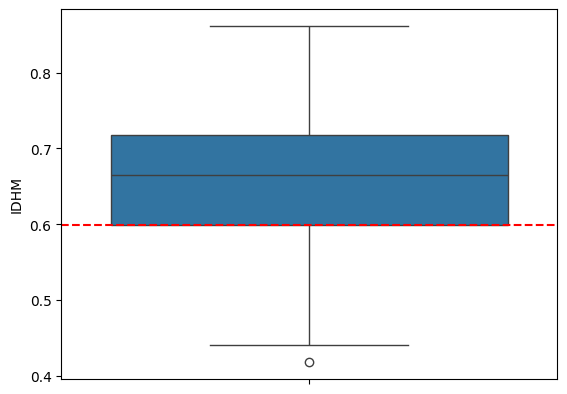

In [45]:
sns.boxplot(y='IDHM', data=dados)
plt.axhline(quartil1, color='r', linestyle='--', label=f'Primeiro quartil: {quartil1:.4f}')

###b) Concentração Geográfica:
Considerando os municípios com menor IDHM, existe uma concentração em algum estado ou distrito? Utilize o conceito de Pareto para fundamentar sua resposta.

In [46]:
idhmBaixo = dados[dados['IDHM'] < quartil1]
count = idhmBaixo['Estado'].value_counts()
totalBaixoIdhm = len(dados)
percentual = (count / totalBaixoIdhm) * 100
percentual = percentual.sort_values(ascending=False)
percentualAc = percentual.cumsum()

print("Percentual de municípios com baixo IDHM por estado:")
print(percentual)
print("\nPercentual acumulado:")
print(percentualAc)

paretoLimite = 80
estadosPareto = percentualAc[percentualAc <= paretoLimite]

print("\nEstados que concentram a maior parte dos municípios com baixo IDHM (80% do total):")
print(estadosPareto)

Percentual de municípios com baixo IDHM por estado:
Estado
BA    4.537303
PI    3.228121
MA    2.761836
PB    2.690100
PE    1.865136
PA    1.703730
AL    1.578192
MG    1.273314
RN    1.255380
AM    0.842898
CE    0.824964
SE    0.753228
TO    0.448350
AC    0.215208
RO    0.161406
RR    0.089670
PR    0.071736
MS    0.071736
GO    0.053802
AP    0.053802
MT    0.035868
RS    0.017934
Name: count, dtype: float64

Percentual acumulado:
Estado
BA     4.537303
PI     7.765423
MA    10.527260
PB    13.217360
PE    15.082496
PA    16.786227
AL    18.364419
MG    19.637733
RN    20.893113
AM    21.736011
CE    22.560976
SE    23.314204
TO    23.762554
AC    23.977762
RO    24.139168
RR    24.228838
PR    24.300574
MS    24.372310
GO    24.426112
AP    24.479914
MT    24.515782
RS    24.533716
Name: count, dtype: float64

Estados que concentram a maior parte dos municípios com baixo IDHM (80% do total):
Estado
BA     4.537303
PI     7.765423
MA    10.527260
PB    13.217360
PE    15.082496
PA

<ipython-input-47-ccf42555e7e3>:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(percentual.index, rotation=45, ha='right')


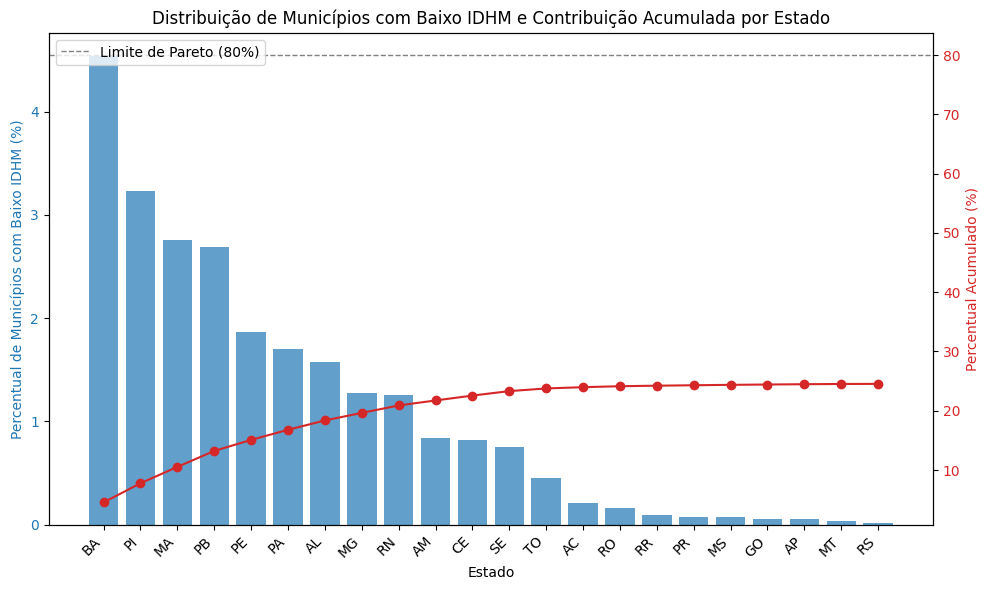

In [47]:
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('Estado')
ax1.set_ylabel('Percentual de Municípios com Baixo IDHM (%)', color=color)
ax1.bar(percentual.index, percentual, color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(percentual.index, rotation=45, ha='right')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Percentual Acumulado (%)', color=color)
ax2.plot(percentualAc.index, percentualAc, color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1, label='Limite de Pareto (80%)')
ax2.legend(loc='upper left')

plt.title('Distribuição de Municípios com Baixo IDHM e Contribuição Acumulada por Estado')
plt.tight_layout()
plt.show()

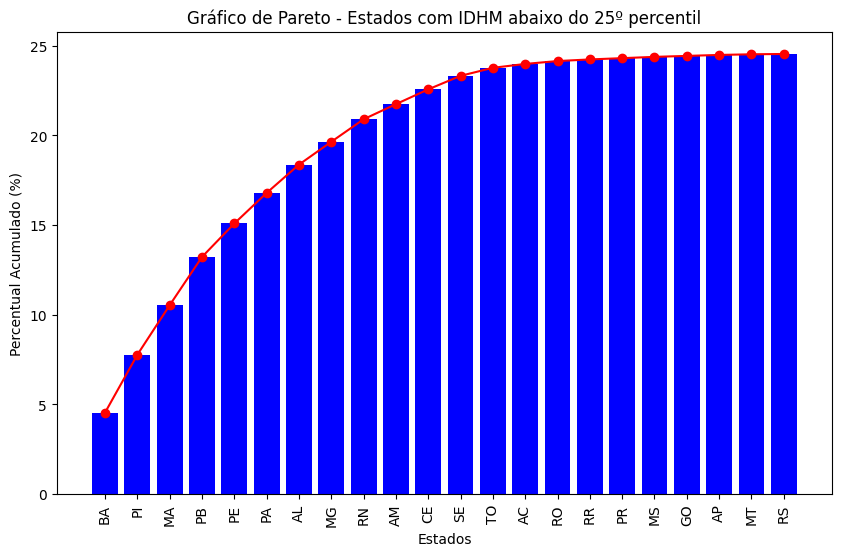

In [48]:
plt.figure(figsize=(10, 6))
plt.bar(estadosPareto.index, estadosPareto.values, color='blue')
plt.plot(estadosPareto.index, estadosPareto.values, color='red', marker='o')
plt.xlabel('Estados')
plt.ylabel('Percentual Acumulado (%)')
plt.title('Gráfico de Pareto - Estados com IDHM abaixo do 25º percentil')
plt.xticks(rotation=90)
plt.show()

O estado da Bahia tem maior frequência de IDHMs menores ou iguais ao percentil 25. Além disso os primeiros estados são do Nordeste.

###c) Classificação ONU:
A ONU classifica o IDH em quatro faixas:
  - Baixo: < 0,550
  - Médio: 0,550 - 0,699
  - Alto: 0,700 - 0,799
  - Muito Alto: >= 0,800
  - Pergunta: Com base nessa classificação, analise a situação atual do Brasil e de cada região.

In [49]:
def classificacao(row):
  if row['IDHM'] >= 0.800:
          return 'Muito Alto'
  elif row['IDHM'] >= 0.700:
          return 'Alto'
  elif row['IDHM'] >= 0.550:
          return 'Médio'
  else:
          return 'Baixo'

dados['Classificação'] = dados.apply(classificacao, axis=1)
count = dados['Classificação'].value_counts()
print(count)

Classificação
Médio         3244
Alto          1951
Baixo          330
Muito Alto      51
Name: count, dtype: int64


In [50]:
estado_para_regiao = {
    'AC': 'Norte', 'AL': 'Nordeste', 'AP': 'Norte', 'AM': 'Norte', 'BA': 'Nordeste',
    'CE': 'Nordeste', 'DF': 'Centro-Oeste', 'ES': 'Sudeste', 'GO': 'Centro-Oeste',
    'MA': 'Nordeste', 'MG': 'Sudeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    'PA': 'Norte', 'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'PR': 'Sul',
    'RJ': 'Sudeste', 'RN': 'Nordeste', 'RO': 'Norte', 'RS': 'Sul', 'SC': 'Sul',
    'SE': 'Nordeste', 'SP': 'Sudeste', 'TO': 'Norte'
}

dados['regiao'] = dados['Estado'].map(estado_para_regiao)

In [51]:
regiaoInteresse = 'Nordeste'
dadosRegiao = dados[dados['regiao'] == regiaoInteresse]
frequencia = dadosRegiao['Classificação'].value_counts().sort_index()

print('Frequência de Categorias de IDHM na Região {regiaoInteresse}:')
print(frequencia)

Frequência de Categorias de IDHM na Região {regiaoInteresse}:
Classificação
Alto       36
Baixo     242
Médio    1518
Name: count, dtype: int64


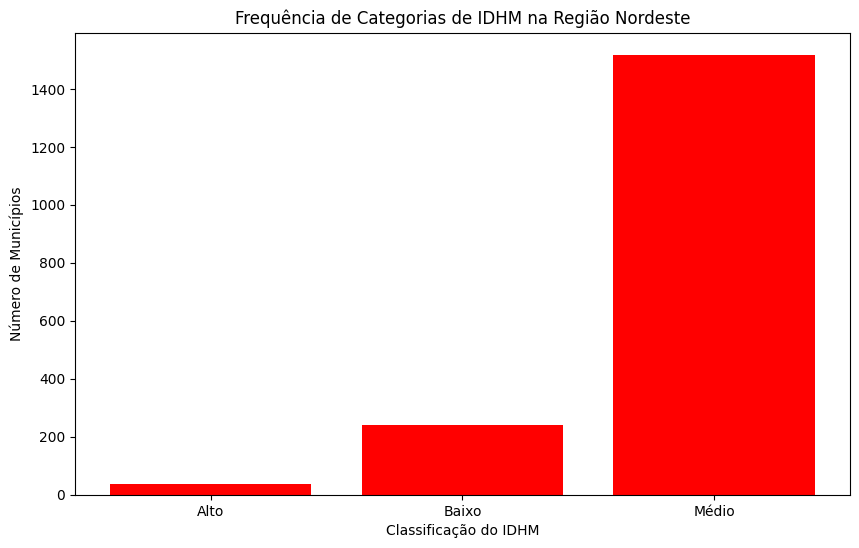

In [52]:
plt.figure(figsize=(10, 6))
plt.bar(frequencia.index, frequencia.values, color='red')
plt.xlabel('Classificação do IDHM')
plt.ylabel('Número de Municípios')
plt.title(f'Frequência de Categorias de IDHM na Região {regiaoInteresse}')
plt.show()


In [53]:
regiaoInteresse = 'Norte'
dadosRegiao = dados[dados['regiao'] == regiaoInteresse]
frequencia = dadosRegiao['Classificação'].value_counts().sort_index()

print('Frequência de Categorias de IDHM na Região {regiaoInteresse}:')
print(frequencia)

Frequência de Categorias de IDHM na Região {regiaoInteresse}:
Classificação
Alto      27
Baixo     68
Médio    340
Name: count, dtype: int64


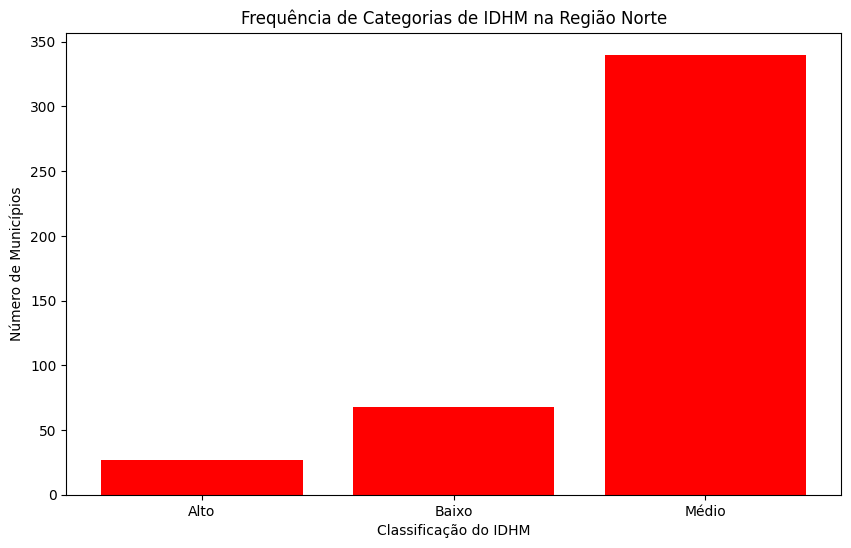

In [54]:
plt.figure(figsize=(10, 6))
plt.bar(frequencia.index, frequencia.values, color='red')
plt.xlabel('Classificação do IDHM')
plt.ylabel('Número de Municípios')
plt.title(f'Frequência de Categorias de IDHM na Região {regiaoInteresse}')
plt.show()


In [55]:
regiaoInteresse = 'Centro-Oeste'
dadosRegiao = dados[dados['regiao'] == regiaoInteresse]
frequencia = dadosRegiao['Classificação'].value_counts().sort_index()

print('Frequência de Categorias de IDHM na Região {regiaoInteresse}:')
print(frequencia)

Frequência de Categorias de IDHM na Região {regiaoInteresse}:
Classificação
Alto          205
Baixo           3
Muito Alto      1
Médio         258
Name: count, dtype: int64


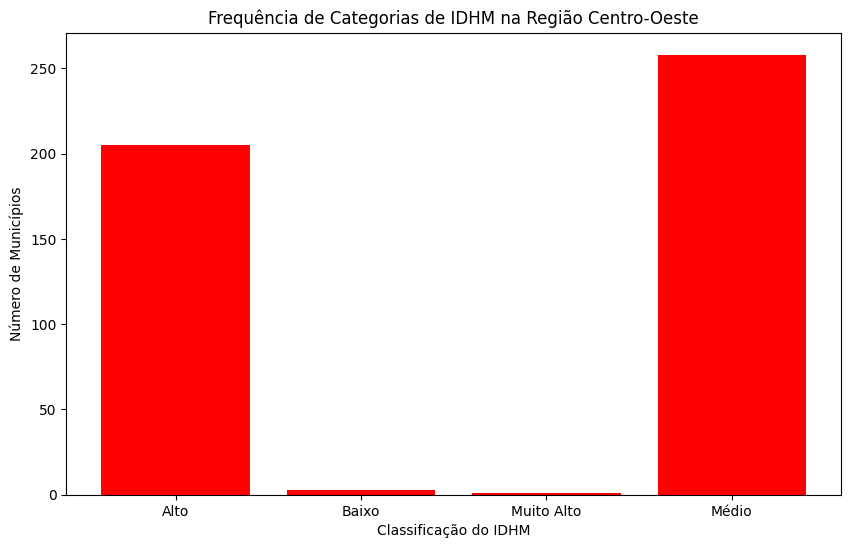

In [56]:
plt.figure(figsize=(10, 6))
plt.bar(frequencia.index, frequencia.values, color='red')
plt.xlabel('Classificação do IDHM')
plt.ylabel('Número de Municípios')
plt.title(f'Frequência de Categorias de IDHM na Região {regiaoInteresse}')
plt.show()


In [57]:
regiaoInteresse = 'Sudeste'
dadosRegiao = dados[dados['regiao'] == regiaoInteresse]
frequencia = dadosRegiao['Classificação'].value_counts().sort_index()

print('Frequência de Categorias de IDHM na Região {regiaoInteresse}:')
print(frequencia)

Frequência de Categorias de IDHM na Região {regiaoInteresse}:
Classificação
Alto          892
Baixo           9
Muito Alto     33
Médio         736
Name: count, dtype: int64


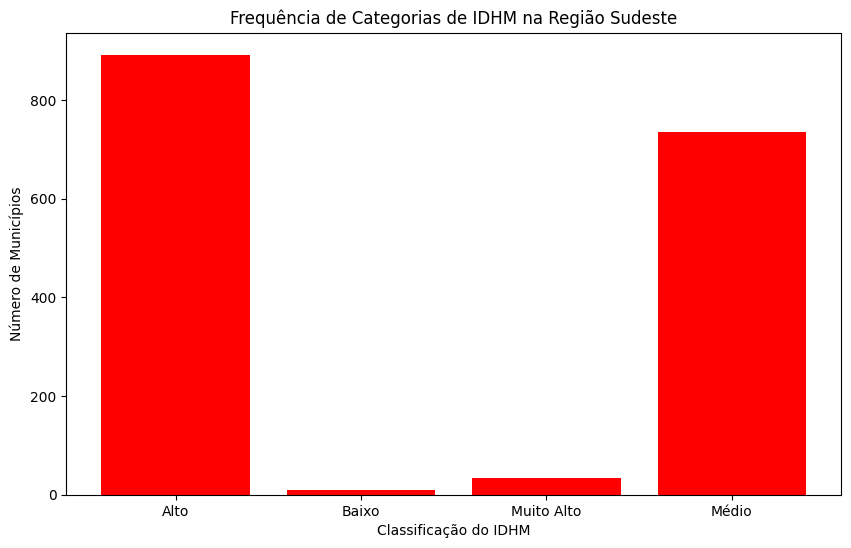

In [58]:
plt.figure(figsize=(10, 6))
plt.bar(frequencia.index, frequencia.values, color='red')
plt.xlabel('Classificação do IDHM')
plt.ylabel('Número de Municípios')
plt.title(f'Frequência de Categorias de IDHM na Região {regiaoInteresse}')
plt.show()


In [59]:
regiaoInteresse = 'Sul'
dadosRegiao = dados[dados['regiao'] == regiaoInteresse]
frequencia = dadosRegiao['Classificação'].value_counts().sort_index()

print(f'Frequência de Categorias de IDHM na Região {regiaoInteresse}:')
print(frequencia)

Frequência de Categorias de IDHM na Região Sul:
Classificação
Alto          790
Baixo           5
Muito Alto     17
Médio         381
Name: count, dtype: int64


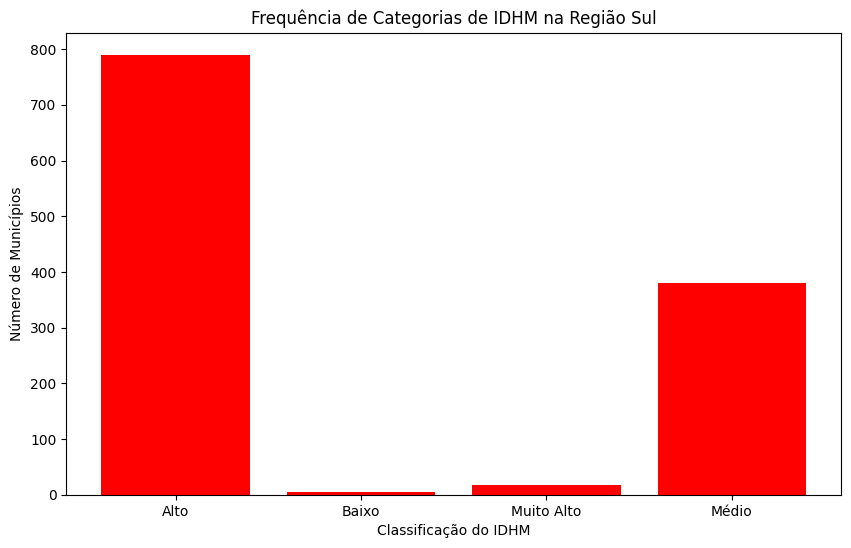

In [60]:
plt.figure(figsize=(10, 6))
plt.bar(frequencia.index, frequencia.values, color='red')
plt.xlabel('Classificação do IDHM')
plt.ylabel('Número de Municípios')
plt.title(f'Frequência de Categorias de IDHM na Região {regiaoInteresse}')
plt.show()


As regiões Norte e Nordeste não têm uma única cidade com o IDHM na classificação "Muito Alto", além de possuírem números discrepantes de municípios com o IDHM na classificação "Baixo" quando comparados às outras regiões. É necessário entender o que está causando essa situação lamentável nas regiões.

A região Sudeste concentra a maior parte das cidades com IDHM muito alto, seguido do Sul e por último Centro-Oeste.

No geral, o país tem muitos municípios na classificação média.

###d) Boxplot por Região:
Construa um boxplot da variável IDHM_Educacao por região (NO, NE, SE, S e CO). Comente as semelhanças e diferenças entre os gráficos.

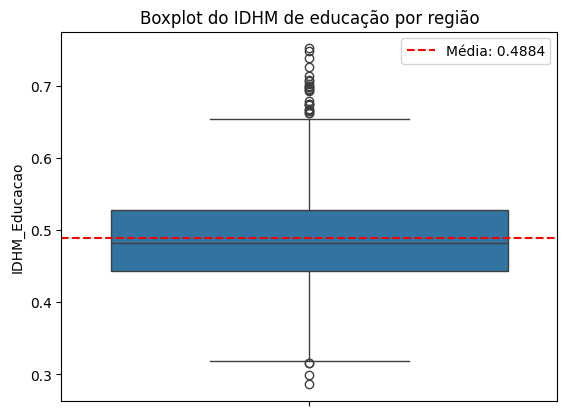

In [61]:
regiaoInteresse = 'Nordeste'
dadosRegiao = dados[dados['regiao'] == regiaoInteresse]
educacao = dadosRegiao['IDHM_Educacao']

sns.boxplot(y=educacao, data=dadosRegiao)
plt.title('Boxplot do IDHM de educação por região')

media = dadosRegiao['IDHM_Educacao'].mean()
plt.axhline(media, color='r', linestyle='--', label=f'Média: {media:.4f}')

plt.legend()
plt.show()

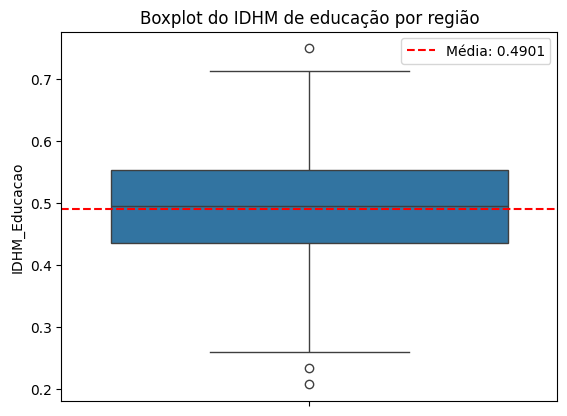

In [62]:
regiaoInteresse = 'Norte'
dadosRegiao = dados[dados['regiao'] == regiaoInteresse]
educacao = dadosRegiao['IDHM_Educacao']

sns.boxplot(y=educacao, data=dadosRegiao)
plt.title('Boxplot do IDHM de educação por região')

media = dadosRegiao['IDHM_Educacao'].mean()
plt.axhline(media, color='r', linestyle='--', label=f'Média: {media:.4f}')

plt.legend()
plt.show()

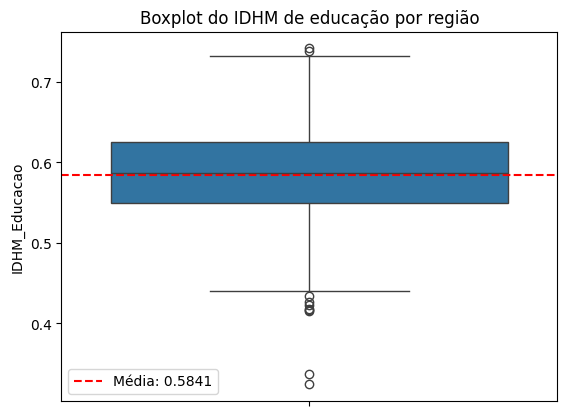

In [63]:
regiaoInteresse = 'Centro-Oeste'
dadosRegiao = dados[dados['regiao'] == regiaoInteresse]
educacao = dadosRegiao['IDHM_Educacao']

sns.boxplot(y=educacao, data=dadosRegiao)
plt.title('Boxplot do IDHM de educação por região')

media = dadosRegiao['IDHM_Educacao'].mean()
plt.axhline(media, color='r', linestyle='--', label=f'Média: {media:.4f}')

plt.legend()
plt.show()

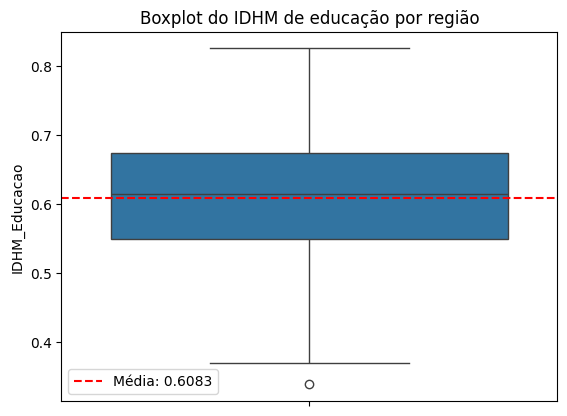

In [64]:
regiaoInteresse = 'Sudeste'
dadosRegiao = dados[dados['regiao'] == regiaoInteresse]
educacao = dadosRegiao['IDHM_Educacao']

sns.boxplot(y=educacao, data=dadosRegiao)
plt.title('Boxplot do IDHM de educação por região')

media = dadosRegiao['IDHM_Educacao'].mean()
plt.axhline(media, color='r', linestyle='--', label=f'Média: {media:.4f}')

plt.legend()
plt.show()

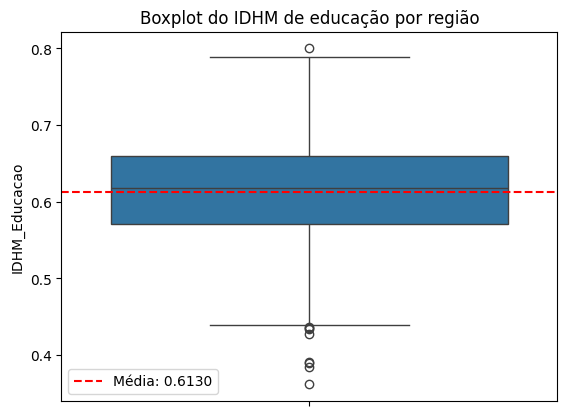

In [65]:
regiaoInteresse = 'Sul'
dadosRegiao = dados[dados['regiao'] == regiaoInteresse]
educacao = dadosRegiao['IDHM_Educacao']

sns.boxplot(y=educacao, data=dadosRegiao)
plt.title('Boxplot do IDHM de educação por região')

media = dadosRegiao['IDHM_Educacao'].mean()
plt.axhline(media, color='r', linestyle='--', label=f'Média: {media:.4f}')

plt.legend()
plt.show()

As regiões Sul, Sudeste e Centro-Oeste têm suas medianas perto de 0.6. Enquanto o Norte e Nordeste não passam de 0.5.

### e) Municípios com Mais Crianças:  
Na região com a menor média de IDHM_Educacao, identifique os municípios que estão acima do 3º quartil nacional em relação à quantidade de crianças com idade entre 1 e 4 anos (variável IBGE_1-4).

In [66]:
mediaRegiao = dados.groupby('regiao')['IDHM_Educacao'].mean()
menorMedia = mediaRegiao.idxmin()
dadosMenorMedia = dados[dados['regiao'] == menorMedia]
quartil3 = dados['IBGE_1-4'].quantile(0.75)
municipiosAcima = dadosMenorMedia[dadosMenorMedia['IBGE_1-4'] > quartil3]

print(f"Municípios da região com a menor média de IDHM_Educacao ({menorMedia}) acima do 3º quartil nacional para a quantidade de crianças entre 1 e 4 anos:")
print(municipiosAcima[['Município', 'IBGE_1-4']])

Municípios da região com a menor média de IDHM_Educacao (Nordeste) acima do 3º quartil nacional para a quantidade de crianças entre 1 e 4 anos:
       Município  IBGE_1-4
16        Recife   54720.0
19      Salvador   91470.0
24     Fortaleza  129766.0
45     Barreiras    8402.0
58         Natal   41558.0
...          ...       ...
3709   Araçoiaba    1158.0
3810   Pirapemas     970.0
5196   Tamandaré    1134.0
5215    Irauçuba    1092.0
5221  Turilândia     987.0

[456 rows x 2 columns]


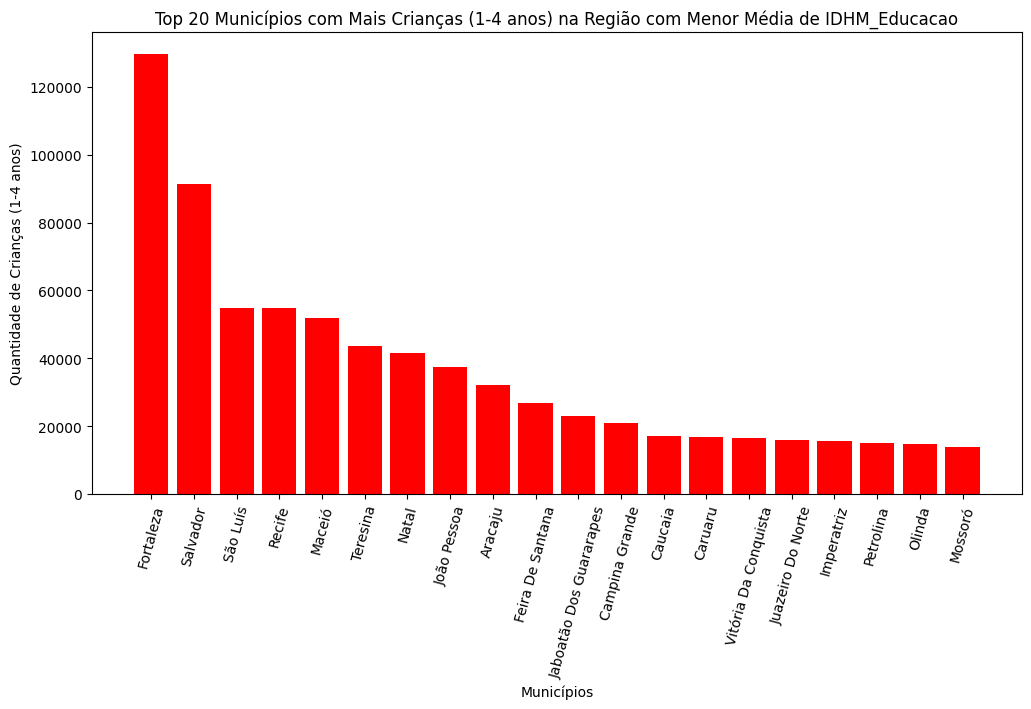

In [67]:
municipiosAcimaSorted = municipiosAcima.sort_values('IBGE_1-4', ascending=False)
top20 = municipiosAcimaSorted.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top20['Município'], top20['IBGE_1-4'], color='red')
plt.xlabel('Municípios')
plt.ylabel('Quantidade de Crianças (1-4 anos)')
plt.title('Top 20 Municípios com Mais Crianças (1-4 anos) na Região com Menor Média de IDHM_Educacao')
plt.xticks(rotation=75)
plt.show()


###f) Empresas de Educação:
Identifique os municípios que estão no 1º quartil nacional em relação à quantidade de empresas do setor educacional (variável COMP_P). Dessa forma, vamos priorizar municípios com poucas empresas de educação.

In [68]:
regiaoInteresse = 'Nordeste'
dadosRegiao = dados[dados['regiao'] == regiaoInteresse]
quartil1 = dadosRegiao['COMP_P'].quantile(0.25)
cidadesQuartil1 = dadosRegiao[dadosRegiao['COMP_P'] <= quartil1]

print(f"Municípios no 1º quartil nacional em relação à quantidade de empresas do setor educacional (limitado a 30 municípios) na região Nordeste:")
print(cidadesQuartil1[['Município', 'COMP_P']])

Municípios no 1º quartil nacional em relação à quantidade de empresas do setor educacional (limitado a 30 municípios) na região Nordeste:
               Município  COMP_P
640             Condeúba     0.0
761         Rio Do Pires     0.0
804         Souto Soares     1.0
1158             Ibipeba     1.0
1355  São Vicente Ferrer     1.0
...                  ...     ...
5570  Novo Santo Antônio     0.0
5571   Floresta Do Piauí     1.0
5572           João Dias     1.0
5574   Lagoinha Do Piauí     0.0
5575              Viçosa     1.0

[508 rows x 2 columns]


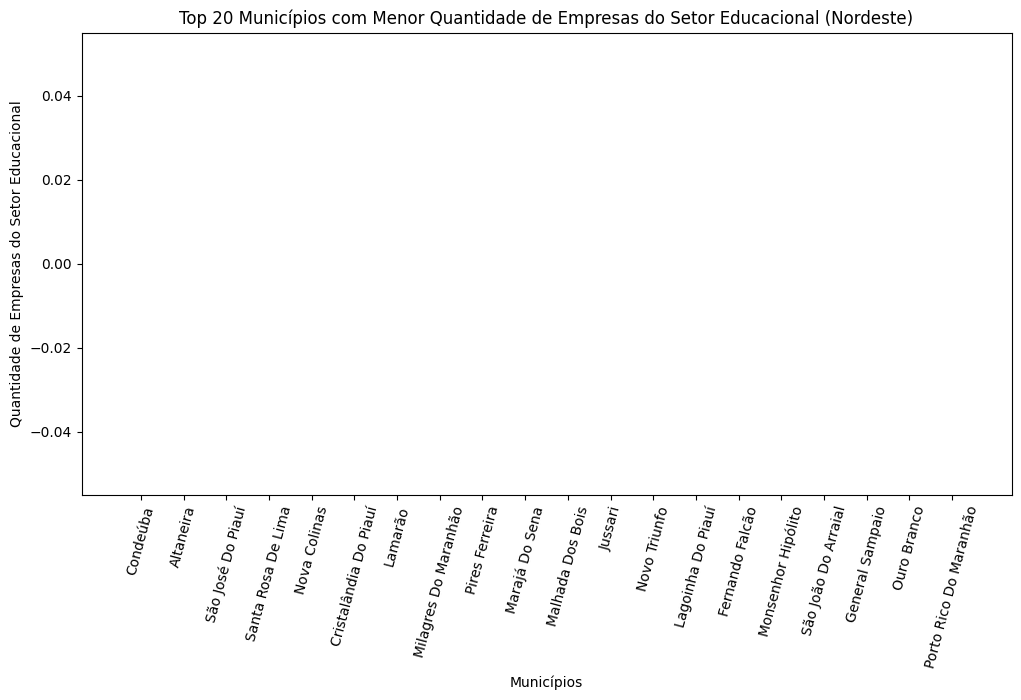

In [69]:
cidadesSorted = cidadesQuartil1.sort_values('COMP_P', ascending=True)
top20Comp = cidadesSorted.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top20Comp['Município'], top20Comp['COMP_P'], color='red')
plt.xlabel('Municípios')
plt.ylabel('Quantidade de Empresas do Setor Educacional')
plt.title('Top 20 Municípios com Menor Quantidade de Empresas do Setor Educacional (Nordeste)')
plt.xticks(rotation=75)
plt.show()

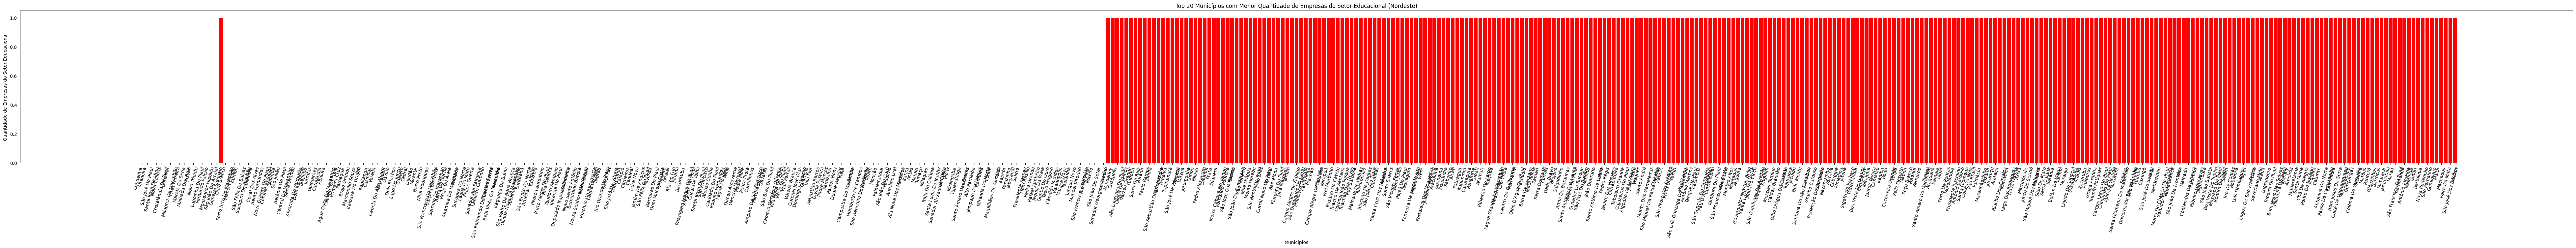

In [70]:
cidadesSorted = cidadesQuartil1.sort_values('COMP_P', ascending=True)
comp = cidadesSorted

plt.figure(figsize=(100, 6))
plt.bar(comp['Município'], comp['COMP_P'], color='red')
plt.xlabel('Municípios')
plt.ylabel('Quantidade de Empresas do Setor Educacional')
plt.title('Top 20 Municípios com Menor Quantidade de Empresas do Setor Educacional (Nordeste)')
plt.xticks(rotation=75)
plt.show()


###g) Prioridade de Investimento:
Considerando as análises anteriores, proponha uma ordem de priorização para investimento na educação dessa região.

Para um investimento seguro, é importante que exista um público com uma demanda não suprida. A garantia de público pode ser medida pela quantidade de crianças em cada município segundo o IBGE; e a medida de demanda pela quantidade de empresas de educação no município, mas como existe muitas cidades com uma ou nenhuma empresa de educação, a quantidade de crianças pode ser um critério de desempate. No caso de um investimento na educação, acredito que o maior peso deve ir para comunidades menos assistidas, podendo usar o IDHM de educação como uma classificação de prioridade.

De qualquer forma, é necessário mais pesquisa sobre o cenário do cenário de educação do Nordeste para desenhar conclusões mais concretas.